In [139]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep as mh
from matplotlib.colors import LogNorm
import math
mh.style.use("ATLAS")
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [140]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]

runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [141]:
def parse_grl_csv(file_path):
    grl_df = pd.read_csv(file_path)
    return grl_df

grl_2022_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2022_physics.csv")
grl_2023_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2023_physics.csv")
grl_2024_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2024_physics.csv")
grl_df = pd.concat([grl_2022_df, grl_2023_df, grl_2024_df], ignore_index=True)

In [142]:
data_files = glob.glob("AnalysisZipFramework/submission/analysis_output-moreHists4/*.root")

calonu_data_files = []
non_caloNu_2024_data_files = []

for file in data_files:
    run_num = int(os.path.basename(file).split('.')[0])

    if runs_caloNu[0] <= run_num <= runs_caloNu[1]:
        calonu_data_files.append(f"{file}")
    if runs_2024_preCaloNu[0] <= run_num <= runs_2024_preCaloNu[1]:
        non_caloNu_2024_data_files.append(f"{file}")
    if runs_2024_afterCaloNu[0] <= run_num <= runs_2024_afterCaloNu[1]:
        non_caloNu_2024_data_files.append(f"{file}")
    

In [143]:
df_data = uproot.concatenate([f"{f}:nt" for f in calonu_data_files], library="pd", filter_name=["VetoNu0_reduced_charge", "VetoNu1_reduced_charge", "CaloNu_total_E_EM"])

In [144]:
df_mc_CaloNu = uproot.concatenate("build/MC_no_truth_cuts_fixed_ENFB8/2024_CaloNu.bck.root:nt", library="pd", filter_name=["VetoNu0_reduced_charge", "VetoNu1_reduced_charge", "CaloNu_total_E_EM", "truth_dec_z_nu"])

In [145]:
df_mc_noCaloNu = uproot.concatenate("build/MC_no_truth_cuts_fixed_ENFB8/2024_noCaloNu.bck.root:nt", library="pd", filter_name=["VetoNu0_reduced_charge", "VetoNu1_reduced_charge", "CaloNu_total_E_EM", "truth_dec_z_nu"])

In [146]:
cut_val = 12.72e3
df_data_below = df_data[df_data["CaloNu_total_E_EM"] < cut_val]
df_data_above = df_data[df_data["CaloNu_total_E_EM"] >= cut_val]

df_mc_CaloNu_below = df_mc_CaloNu[df_mc_CaloNu["CaloNu_total_E_EM"] < cut_val]
df_mc_CaloNu_above = df_mc_CaloNu[df_mc_CaloNu["CaloNu_total_E_EM"] >= cut_val]

# front = [-2987.39, -2246.18]
front = [-4000, -2246.18]
# back = [-2246.18, -1946.18]
back = [-2246.18, -1000]

MC Front Region: 6082, MC Back Region: 18564, MC Total: 24648
MC Front Fraction: 24.68%, MC Back Fraction: 75.32%


<Axes: xlabel='VetoNu0 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

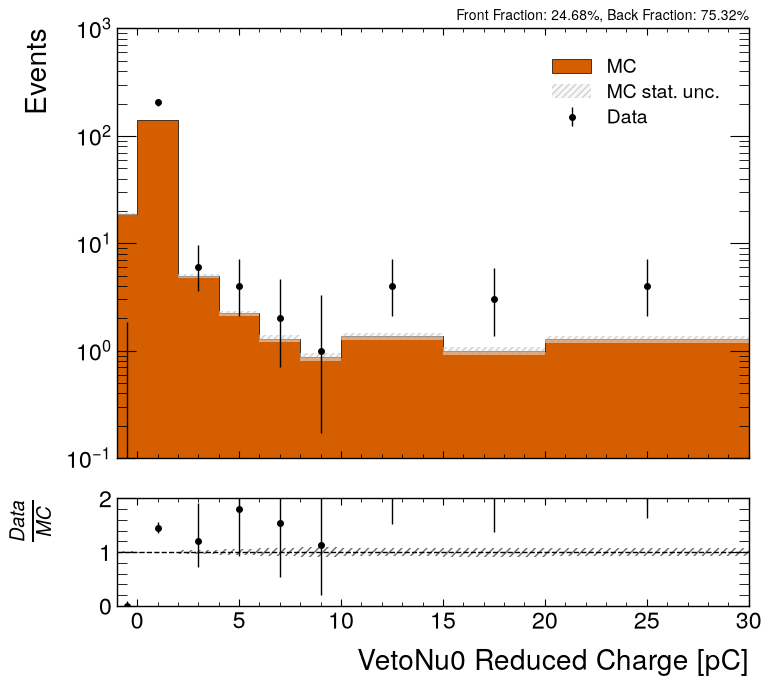

In [147]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]
h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data["VetoNu0_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu["VetoNu0_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu[(df_mc_CaloNu["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu[(df_mc_CaloNu["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")

# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_labels=['MC'],
 xlabel='VetoNu0 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")

mh.mpl_magic(soft_fail=True) # Autofit label


MC Front Region: 2055, MC Back Region: 18563, MC Total: 20620
MC Front Fraction: 9.97%, MC Back Fraction: 90.02%


<Axes: xlabel='VetoNu0 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

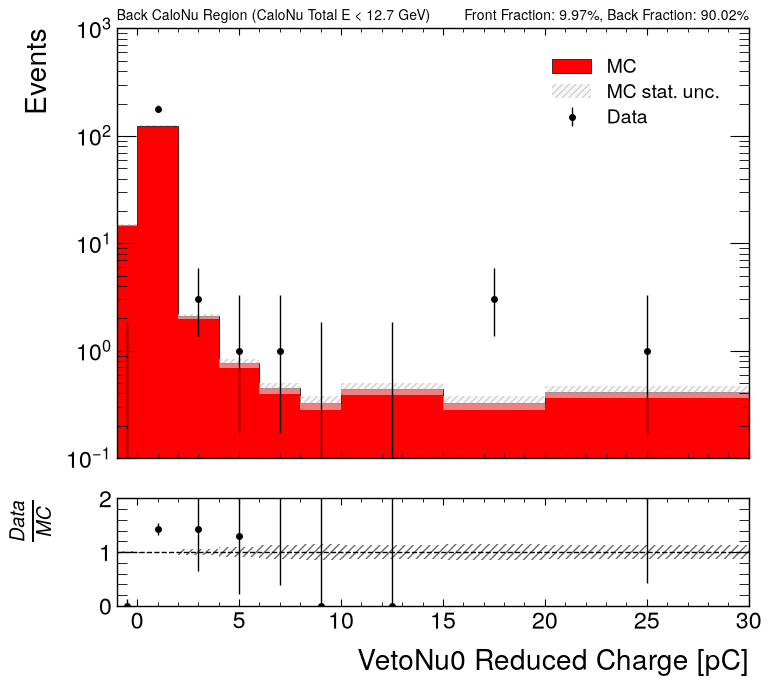

In [148]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]

h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_below["VetoNu0_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu_below["VetoNu0_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu_below[(df_mc_CaloNu_below["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu_below["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu_below[(df_mc_CaloNu_below["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu_below["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu_below.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")


# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_labels=['MC'],
 stacked_colors=["red"],
 xlabel='VetoNu0 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_title(f'Back CaloNu Region (CaloNu Total E < {cut_val/1000:.1f} GeV)', fontsize=10, loc="left")
ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


MC Front Region: 4013, MC Back Region: 1, MC Total: 4014
MC Front Fraction: 99.98%, MC Back Fraction: 0.02%


<Axes: xlabel='VetoNu0 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

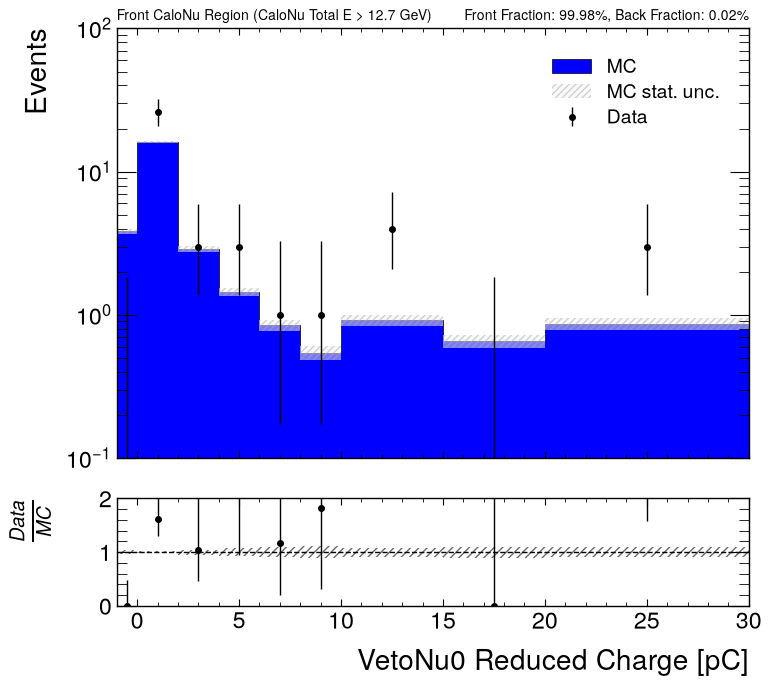

In [149]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]

h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_above["VetoNu0_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu_above["VetoNu0_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu_above[(df_mc_CaloNu_above["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu_above["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu_above[(df_mc_CaloNu_above["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu_above["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu_above.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")



# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_colors=["blue"],
 stacked_labels=['MC'],
 xlabel='VetoNu0 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_title(f'Front CaloNu Region (CaloNu Total E > {cut_val/1000:.1f} GeV)', fontsize=10, loc="left")
ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


MC Front Region: 6082, MC Back Region: 18564, MC Total: 24648
MC Front Fraction: 24.68%, MC Back Fraction: 75.32%


<Axes: xlabel='VetoNu1 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

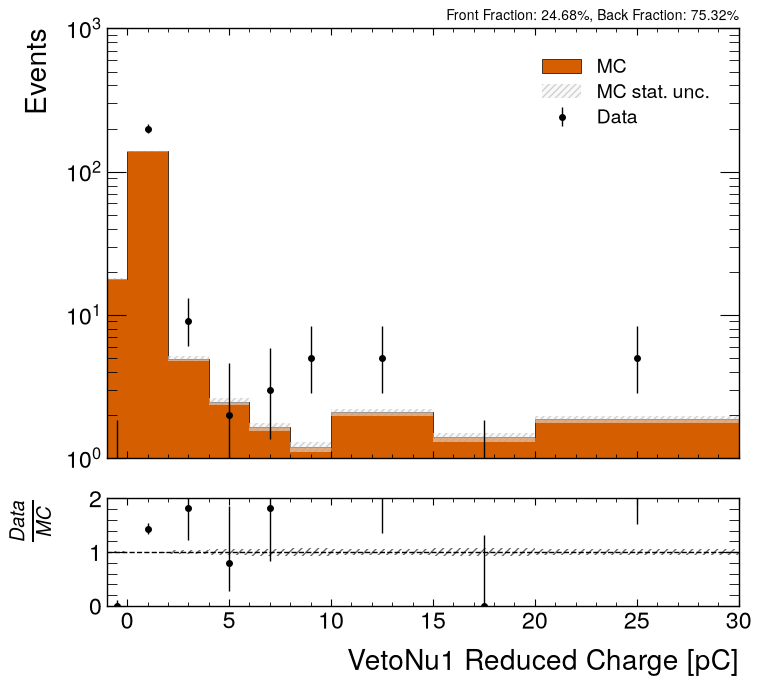

In [150]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]
h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data["VetoNu1_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu["VetoNu1_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu[(df_mc_CaloNu["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu[(df_mc_CaloNu["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")

# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_labels=['MC'],
 xlabel='VetoNu1 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")
ax_main.set_yscale('log')
mh.mpl_magic(soft_fail=True) # Autofit label


MC Front Region: 2055, MC Back Region: 18563, MC Total: 20620
MC Front Fraction: 9.97%, MC Back Fraction: 90.02%


<Axes: xlabel='VetoNu1 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

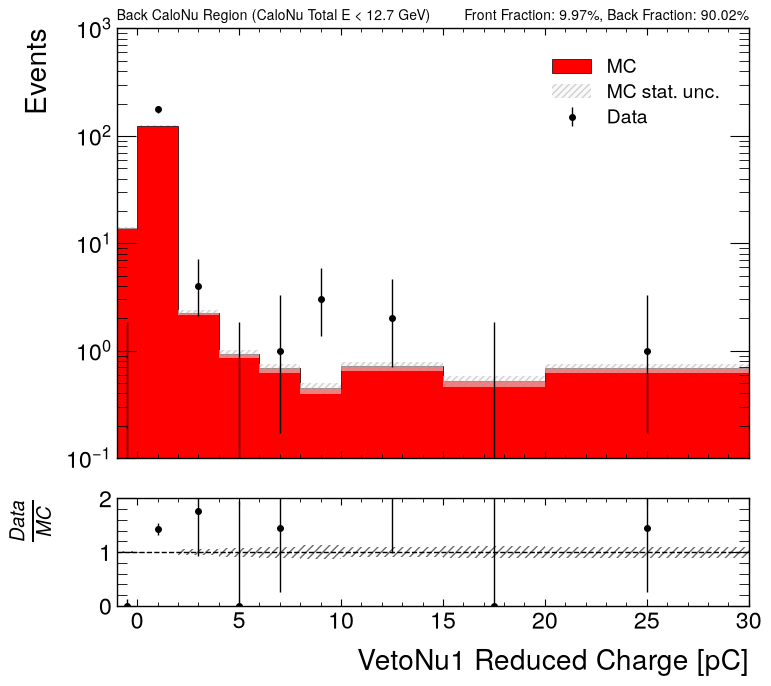

In [151]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]

h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_below["VetoNu1_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu_below["VetoNu1_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu_below[(df_mc_CaloNu_below["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu_below["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu_below[(df_mc_CaloNu_below["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu_below["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu_below.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")


# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_labels=['MC'],
 stacked_colors=["red"],
 xlabel='VetoNu1 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_title(f'Back CaloNu Region (CaloNu Total E < {cut_val/1000:.1f} GeV)', fontsize=10, loc="left")
ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


MC Front Region: 4013, MC Back Region: 1, MC Total: 4014
MC Front Fraction: 99.98%, MC Back Fraction: 0.02%


<Axes: xlabel='VetoNu1 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

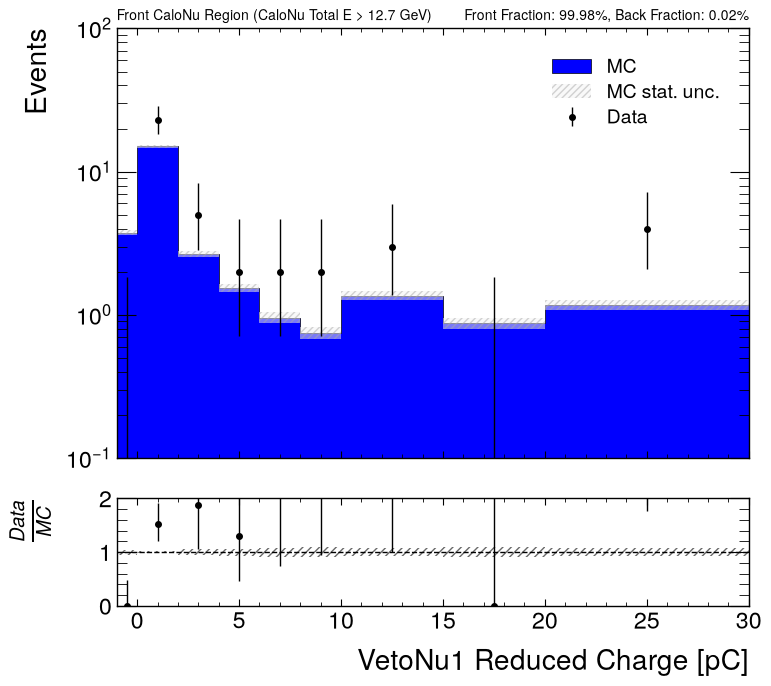

In [152]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]

h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_above["VetoNu1_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu_above["VetoNu1_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu_above[(df_mc_CaloNu_above["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu_above["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu_above[(df_mc_CaloNu_above["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu_above["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu_above.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")


# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_colors=["blue"],
 stacked_labels=['MC'],
 xlabel='VetoNu1 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_title(f'Front CaloNu Region (CaloNu Total E > {cut_val/1000:.1f} GeV)', fontsize=10, loc="left")
ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label
